<a href="https://colab.research.google.com/github/villerbond/avito-text-orientation/blob/main/notebooks/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Исследование тестовых данных**

In [26]:
from pathlib import Path

PROJECT_DIR = Path("/content/project")

TEST_DIR = PROJECT_DIR / "data" / "test"
TRAIN_DIR = PROJECT_DIR / "data" / "train"

for folder in [TEST_DIR, TRAIN_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(PROJECT_DIR)

/content/project


Скачиваем архив с тестовыми данными.

In [47]:
import requests

YANDEX_URL = "https://disk.360.yandex.ru/d/ha0Q70T7ie-0_w"
ARCHIVE_PATH = PROJECT_DIR / "data" / "test_data.zip"

def download_yandex_file(public_url, save_path):
    api = "https://cloud-api.yandex.net/v1/disk/public/resources/download"

    download_url = requests.get(
        api,
        params={"public_key": public_url}
    ).json()["href"]

    with requests.get(download_url, stream=True) as r:
        r.raise_for_status()
        with open(save_path, "wb") as f:
            for chunk in r.iter_content(8192):
                f.write(chunk)

    print(f"Saved to {save_path}")


if not ARCHIVE_PATH.exists():
    download_yandex_file(YANDEX_URL, ARCHIVE_PATH)
else:
    print("Archive already exists.")

Archive already exists.


In [48]:
print(f"Archive size: {ARCHIVE_PATH.stat().st_size / 1024**2:.1f} MB")

Archive size: 649.9 MB


In [42]:
import zipfile

if not any(TEST_DIR.iterdir()):
    with zipfile.ZipFile(ARCHIVE_PATH, "r") as z:
        z.extractall(TEST_DIR)
    print("Archive extracted.")
else:
    print("Data already extracted.")

Data already extracted.


Смотрим структуру распакованного архива.

In [43]:
files = sorted(TEST_DIR.rglob("*"))

for f in files[:10]:
    print(f.relative_to(TEST_DIR))

sample_submission.csv
test
test/images
test/images/test_00000.png
test/images/test_00001.png
test/images/test_00002.png
test/images/test_00003.png
test/images/test_00004.png
test/images/test_00005.png
test/images/test_00006.png


In [44]:
image_files = [
    p for p in TEST_DIR.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

print(f"Images found: {len(image_files)}")
print(image_files[:5])

Images found: 20000
[PosixPath('/content/project/data/test/test/images/test_12968.png'), PosixPath('/content/project/data/test/test/images/test_00613.png'), PosixPath('/content/project/data/test/test/images/test_11872.png'), PosixPath('/content/project/data/test/test/images/test_04759.png'), PosixPath('/content/project/data/test/test/images/test_07566.png')]


Смотрим случайные примеры текстовых кропов

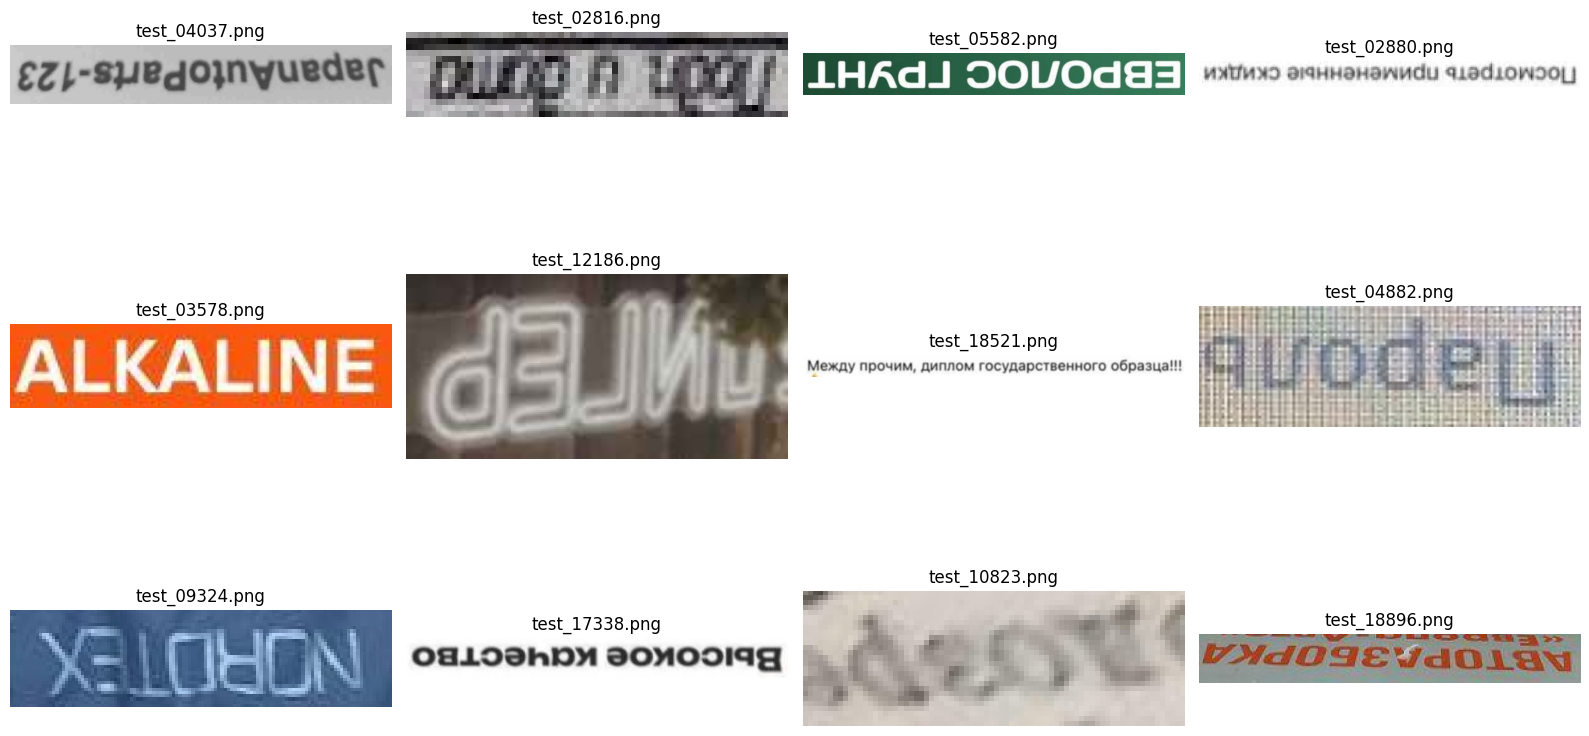

In [52]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

sample_files = random.sample(image_files, 12)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, path in zip(axes.ravel(), sample_files):
    ax.imshow(Image.open(path))
    ax.set_title(path.name, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

Анализируем размеры изображений

In [51]:
sizes = []

for path in image_files:
    with Image.open(path) as img:
        sizes.append(img.size)

widths = [w for w, _ in sizes]
heights = [h for _, h in sizes]
ratios = [w / h for w, h in sizes]

print(f"Width : min={min(widths)}, max={max(widths)}, mean={sum(widths)/len(widths):.1f}")
print(f"Height: min={min(heights)}, max={max(heights)}, mean={sum(heights)/len(heights):.1f}")
print(f"Ratio : min={min(ratios):.2f}, max={max(ratios):.2f}, mean={sum(ratios)/len(ratios):.2f}")

Width : min=25, max=1599, mean=357.6
Height: min=10, max=492, mean=64.4
Ratio : min=0.72, max=49.67, mean=6.22


В тестовом наборе содержится 20000 текстовых кропов.

Размеры изображений сильно различаются: ширина изменяется от 25 до 1599 пикселей, а высота - от 10 до 492 пикселей.

Большинство изображений значительно шире своей высоты (среднее отношение сторон около 6.2), что соответствует длинным текстовым строкам.

Такая вариативность размеров означает, что перед подачей изображений в модель потребуется единый этап предобработки - изменение размера изображений. В идеале сохранять пропорции с добавлением паддингом, но сперва можно просто попробовать делать простой resize как baseline, так как задача именно классифицировать ориентацию, а не считывать текст.